In [1]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('../data/diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [3]:
# statistic summary
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [4]:
# check missing values
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [5]:
# check duplicates
df.duplicated().sum()

0

In [6]:
 df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

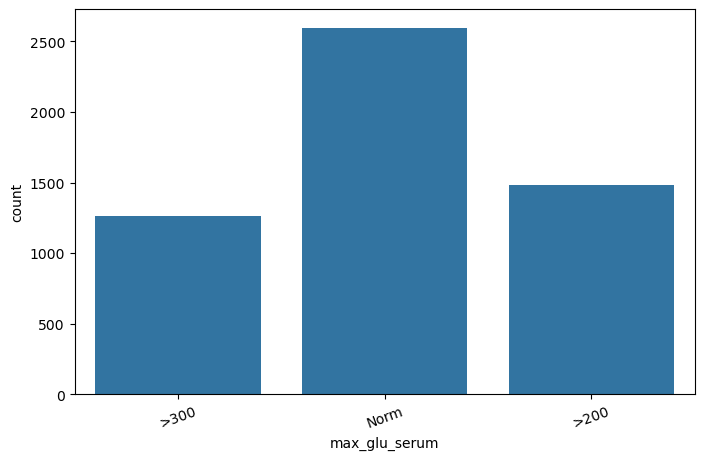

In [7]:
# check missing values 
d_check = df[['max_glu_serum']] #, 'A1Cresult']]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='max_glu_serum', data=df)
plt.xticks(rotation=20)
plt.show()

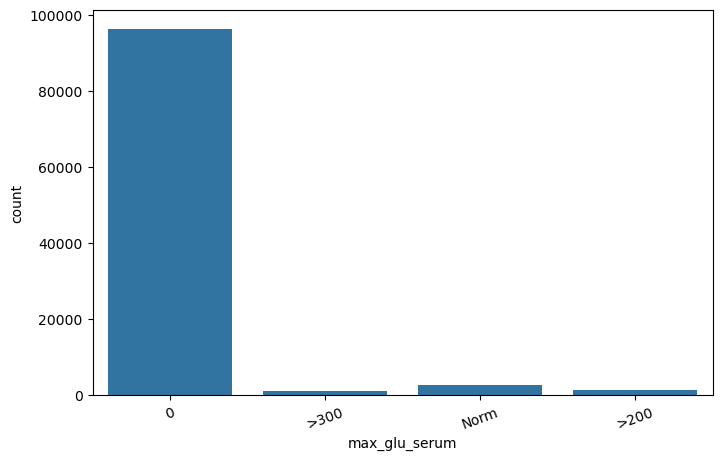

In [8]:
# Replace 'None' to 0
df['max_glu_serum']=df['max_glu_serum'].fillna(0)
df['max_glu_serum']

plt.figure(figsize=(8,5))
sns.countplot(x='max_glu_serum', data=df)
plt.xticks(rotation=20)
plt.show()

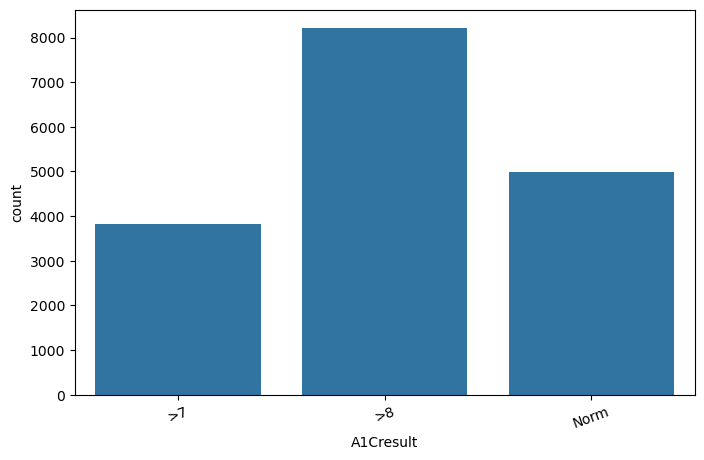

In [9]:
# check missing values 
d_check = df[['A1Cresult']]

plt.figure(figsize=(8,5))
sns.countplot(x='A1Cresult', data=df)
plt.xticks(rotation=20)
plt.show()

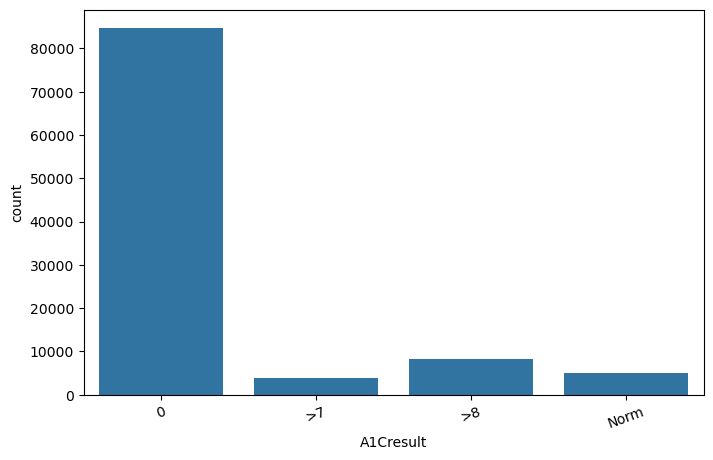

In [10]:
# Replace 'None' to 0
df['A1Cresult'] = df['A1Cresult'].fillna(0)
plt.figure(figsize=(8,5))
sns.countplot(x='A1Cresult', data=df)
plt.xticks(rotation=20)
plt.show()

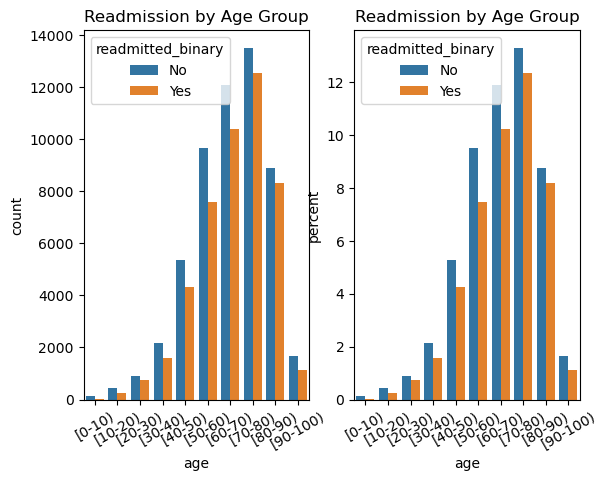

In [11]:
# Create binary readmission
df['readmitted_binary'] = df['readmitted'].replace({
    'NO': 'No',
    '<30': 'Yes',
    '>30': 'Yes'
})

plt.subplot(1,2,1)
sns.countplot(x='age', hue='readmitted_binary', data = df)
plt.title('Readmission by Age Group')
plt.xticks(rotation = 30)

plt.subplot(1,2,2)
sns.countplot(x='age', hue='readmitted_binary', data = df, stat='percent')
plt.title('Readmission by Age Group')
plt.xticks(rotation = 30)
plt.show()

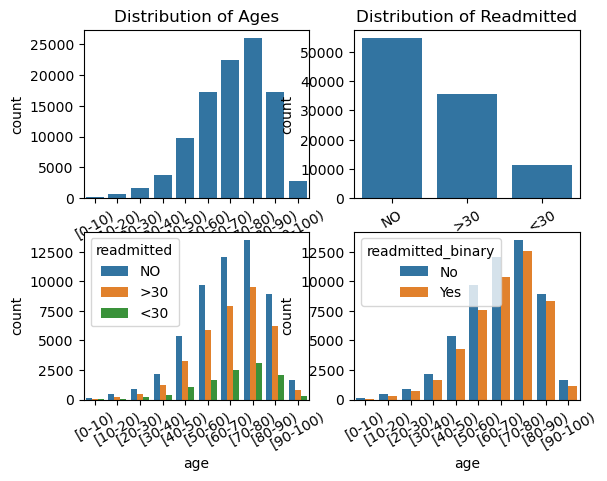

In [12]:
# Exploratory analysis
# Q1: Which age groups are readmitted most? #age readmitted
# check age data
d1 = df['age']
d1.head()

import seaborn as sns
import matplotlib.pyplot as plt

# fig = plt.figure()
plt.subplot(2, 2, 1)
sns.countplot(x = 'age', data = df)
plt.title('Distribution of Ages')
plt.xticks(rotation = 30)

# check readmitted data
d2 = df['readmitted']
d2.head()

plt.subplot(2,2,2)
sns.countplot(x = 'readmitted', data = df)
plt.xticks(rotation = 30)
plt.title('Distribution of Readmitted')

plt.subplot(2,2,3)
sns.countplot(x='age', hue='readmitted', data = df)
# plt.title('Readmission by Age Group')
plt.xticks(rotation = 30)

plt.subplot(2,2,4)
sns.countplot(x='age', hue='readmitted_binary', data = df)
# plt.title('Readmission by Age Group')
plt.xticks(rotation = 30)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

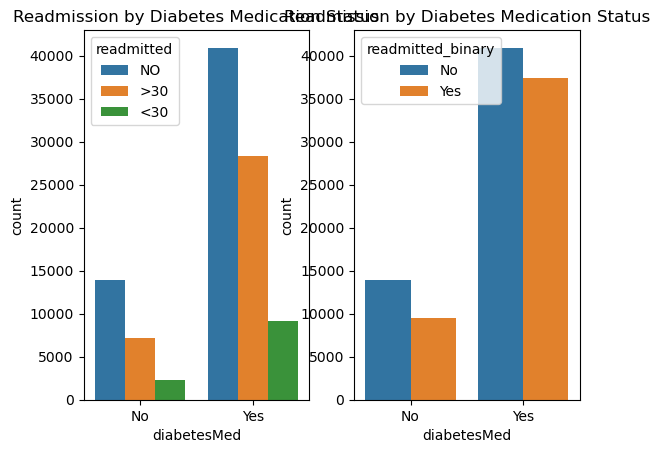

In [13]:
# Exploratory analysis
# Q2: Does diabetes medication relate to readmission?
d3 = df['diabetesMed']
d3.head()

plt.subplot(1,2,1)
sns.countplot(x='diabetesMed', hue='readmitted', data=df)
plt.title('Readmission by Diabetes Medication Status')
plt.subplot(1,2,2)
sns.countplot(x='diabetesMed', hue='readmitted_binary', data=df)
plt.title('Readmission by Diabetes Medication Status')
plt.show

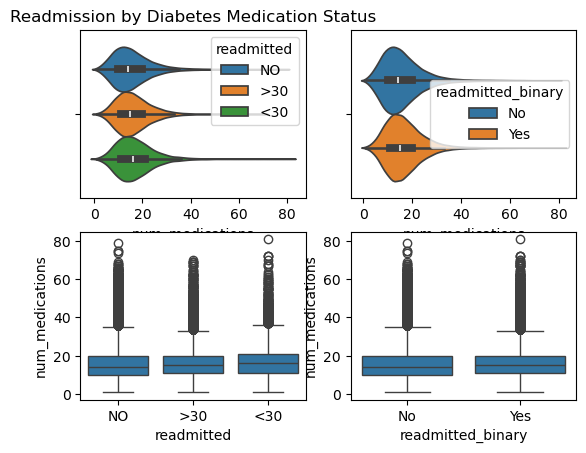

In [14]:
# Exploratory analysis
# Q3: Do medication patterns matter?
plt.subplot(2,2,1)
sns.violinplot(x='num_medications',hue='readmitted',data=df)
plt.title('Readmission by Diabetes Medication Status')
plt.subplot(2,2,2)
sns.violinplot(x='num_medications',hue='readmitted_binary',data=df)
plt.subplot(2,2,3)
sns.boxplot(x='readmitted', y='num_medications', data=df)
plt.subplot(2,2,4)
sns.boxplot(x='readmitted_binary', y='num_medications', data=df)
plt.show()

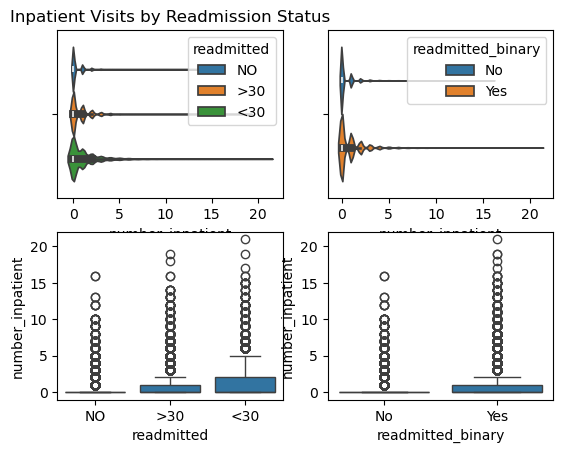

In [15]:
# Exploratory analysis
# Does hospital stay length predict readmission?
plt.subplot(2,2,1)
sns.violinplot(x='number_inpatient', hue='readmitted', data=df)
plt.title('Inpatient Visits by Readmission Status')
plt.subplot(2,2,2)
sns.violinplot(x='number_inpatient', hue='readmitted_binary', data=df)
plt.subplot(2,2,3)
sns.boxplot(y='number_inpatient', x='readmitted', data=df)
plt.subplot(2,2,4)
sns.boxplot(y='number_inpatient', x='readmitted_binary', data=df)
plt.show()

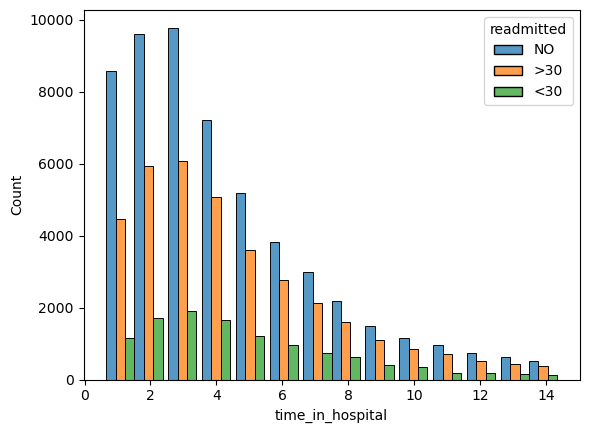

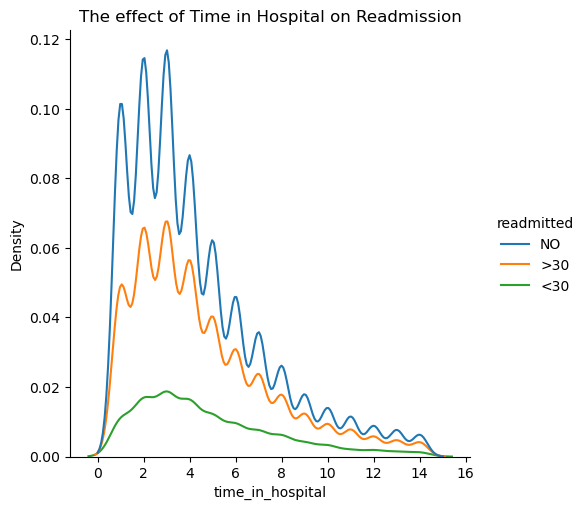

In [16]:
# Does hospital stay length affect readmission?
# sns.violinplot(x='time_in_hospital', hue='readmitted', data=df)
# plt.show()

#sns.histplot(data=df['time_in_hospital'])
sns.histplot(x='time_in_hospital', hue='readmitted', data=df, multiple="dodge", shrink=5)

sns.displot(df, x="time_in_hospital", hue="readmitted", kind="kde") #, multiple="stack")

# sns.displot(df, x="time_in_hospital", y="readmitted")

plt.title('The effect of Time in Hospital on Readmission')
plt.show()

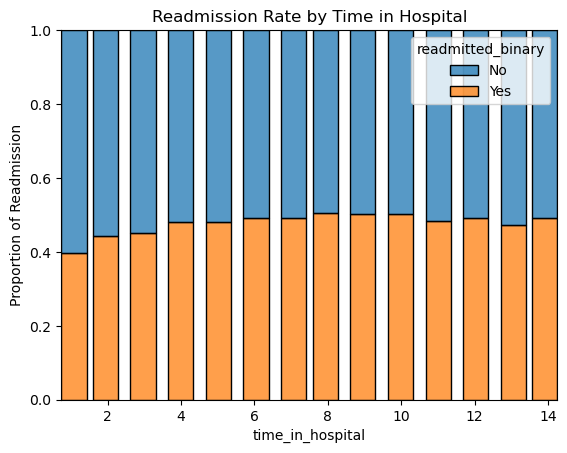

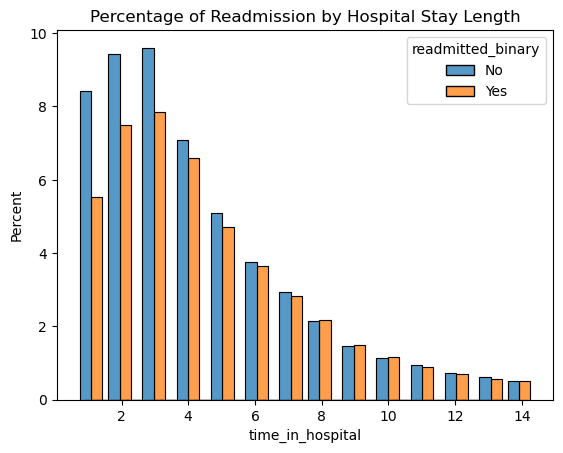

In [17]:
# sns.histplot(x='time_in_hospital', hue='readmitted_binary', data=df, multiple="dodge", shrink=5)
sns.histplot(x='time_in_hospital', hue='readmitted_binary', data=df, multiple='fill', shrink=4)
plt.title('Readmission Rate by Time in Hospital')
plt.ylabel('Proportion of Readmission')
plt.show()

sns.histplot(x='time_in_hospital', hue='readmitted_binary', data=df, stat='percent', 
             multiple='dodge', shrink=4)
plt.title('Percentage of Readmission by Hospital Stay Length')
plt.show()

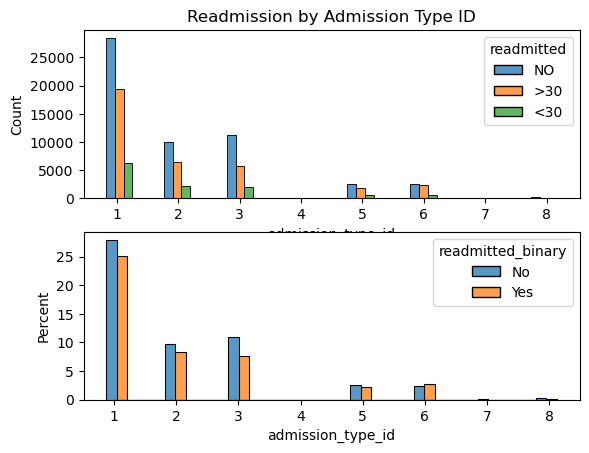

In [18]:
# Which admission types are highest risk?
plt.subplot(2,1,1)
sns.histplot(x='admission_type_id', hue='readmitted', data=df, multiple="dodge", shrink=5)
plt.title('Readmission by Admission Type ID')
plt.subplot(2,1,2)
sns.histplot(x='admission_type_id', hue='readmitted_binary', data=df, stat='percent', 
             multiple='dodge', shrink=4)
# plt.title('Readmission by Admission Type ID')
plt.show()

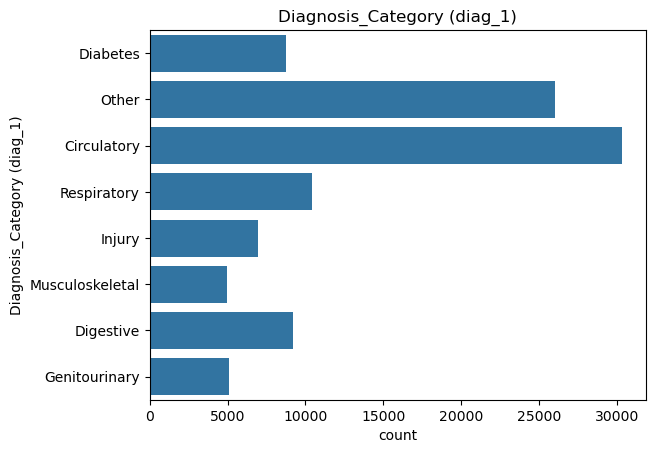

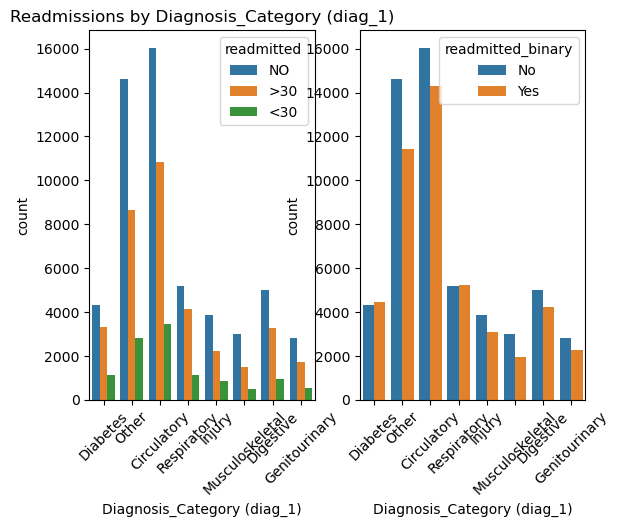

In [19]:
# Which diagnoses are high risk?
def diagnosis_category(code):
    code1 = str(code)
    if code.startswith('250'):
        return 'Diabetes'
    try:
        code_num = float(code)
        if 390 <= code_num <= 459:
            return 'Circulatory' 
        elif 460 <= code_num <= 519:
            return 'Respiratory'
        elif 520 <= code_num <= 579:
            return 'Digestive'
        elif 800 <= code_num <= 999:
            return 'Injury' 
        elif 710 <= code_num <= 739:
            return 'Musculoskeletal'  
        elif 580 <= code_num <= 629:
            return 'Genitourinary'
        else:
            return 'Other'
    except:
        return 'Other'

# Diagnosis categories for diag_1 numbers
df['Diagnosis_Category (diag_1)'] = df['diag_1'].apply(diagnosis_category)
df.head()
df['Diagnosis_Category (diag_2)'] = df['diag_2'].apply(diagnosis_category)
df.head()
df['Diagnosis_Category (diag_3)'] = df['diag_3'].apply(diagnosis_category)
df.head()

sns.countplot(df['Diagnosis_Category (diag_1)'])
plt.title('Diagnosis_Category (diag_1)')
plt.show()

plt.subplot(1,2,1)
sns.countplot(x='Diagnosis_Category (diag_1)', hue='readmitted', data=df)
plt.title('Readmissions by Diagnosis_Category (diag_1)')
plt.xticks(rotation = 45)
plt.subplot(1,2,2)
sns.countplot(x='Diagnosis_Category (diag_1)', hue='readmitted_binary', data=df)
plt.xticks(rotation = 45)
plt.show()


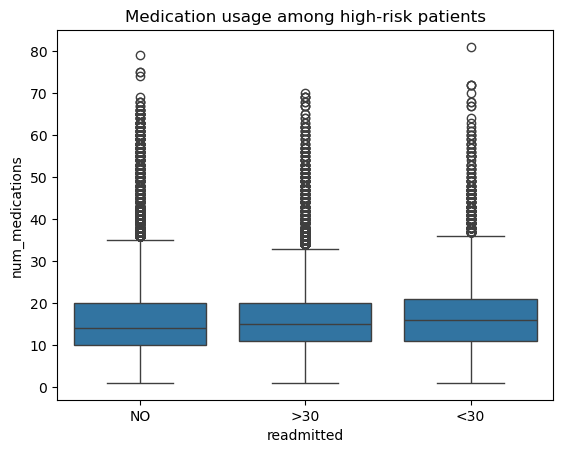

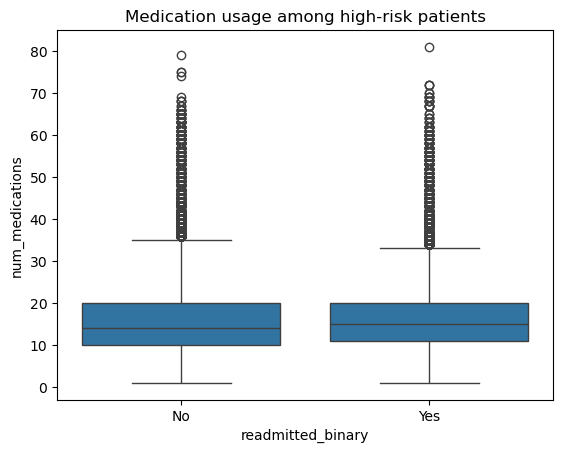

In [20]:
sns.boxplot(y='num_medications', x='readmitted', data=df)
plt.title('Medication usage among high-risk patients')
plt.show()

sns.boxplot(y='num_medications', x='readmitted_binary', data=df)
plt.title('Medication usage among high-risk patients')
plt.show()

In [21]:
##### Machine Learning ######
# classify readmission risk
# models: Logistic Regression, Randon Forest, XGBoost

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_binary,Diagnosis_Category (diag_1),Diagnosis_Category (diag_2),Diagnosis_Category (diag_3)
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,NO,No,Diabetes,Other,Other
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,No,No,Ch,Yes,>30,Yes,Other,Diabetes,Other
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,Yes,NO,No,Other,Diabetes,Other
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,No,No,Ch,Yes,NO,No,Other,Diabetes,Circulatory
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,No,No,Ch,Yes,NO,No,Other,Other,Diabetes


In [22]:
# Create status of readmission
df['readmitted_status'] = df['readmitted'].replace({
    'NO': '0',
    '<30': '1',
    '>30': '2'
})
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_binary,Diagnosis_Category (diag_1),Diagnosis_Category (diag_2),Diagnosis_Category (diag_3),readmitted_status
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,NO,No,Diabetes,Other,Other,0
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,No,Ch,Yes,>30,Yes,Other,Diabetes,Other,2
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,Yes,NO,No,Other,Diabetes,Other,0
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,No,Ch,Yes,NO,No,Other,Diabetes,Circulatory,0
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,No,Ch,Yes,NO,No,Other,Other,Diabetes,0


In [23]:
# replace '?' to 'None' in medical_specialty
df['medical_specialty_1'] = df['medical_specialty'].replace({
    '?': 'None'})
df['medical_specialty_1'].head()

0    Pediatrics-Endocrinology
1                        None
2                        None
3                        None
4                        None
Name: medical_specialty_1, dtype: object

In [24]:
# Remove unnecessary columns
df1 = df.drop(columns = ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty',
                         'readmitted', 'readmitted_status', 'diag_1', 'diag_2', 'diag_3'])
df1.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary,Diagnosis_Category (diag_1),Diagnosis_Category (diag_2),Diagnosis_Category (diag_3),medical_specialty_1
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,Diabetes,Other,Other,Pediatrics-Endocrinology
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,No,No,Ch,Yes,Yes,Other,Diabetes,Other,None
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,Yes,No,Other,Diabetes,Other,None
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,No,No,Ch,Yes,No,Other,Diabetes,Circulatory,None
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,No,No,Ch,Yes,No,Other,Other,Diabetes,None


In [25]:
# Encode categorical variables -> numerical columns, yes/no
df1_encoded = pd.get_dummies(df1, drop_first = True)
df1_encoded.head()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,medical_specialty_1_Surgery-General,medical_specialty_1_Surgery-Maxillofacial,medical_specialty_1_Surgery-Neuro,medical_specialty_1_Surgery-Pediatric,medical_specialty_1_Surgery-Plastic,medical_specialty_1_Surgery-PlasticwithinHeadandNeck,medical_specialty_1_Surgery-Thoracic,medical_specialty_1_Surgery-Vascular,medical_specialty_1_SurgicalSpecialty,medical_specialty_1_Urology
0,6,25,1,1,41,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,1,1,7,3,59,0,18,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,1,1,7,2,11,5,13,2,0,1,...,False,False,False,False,False,False,False,False,False,False
3,1,1,7,2,44,1,16,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,1,1,7,1,51,0,8,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [26]:
# define y target variable
y = df1_encoded['readmitted_binary_Yes']
y.head()

0    False
1     True
2    False
3    False
4    False
Name: readmitted_binary_Yes, dtype: bool

In [27]:
# define X features
X = df1_encoded.drop('readmitted_binary_Yes', axis = 1)
X.head()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,medical_specialty_1_Surgery-General,medical_specialty_1_Surgery-Maxillofacial,medical_specialty_1_Surgery-Neuro,medical_specialty_1_Surgery-Pediatric,medical_specialty_1_Surgery-Plastic,medical_specialty_1_Surgery-PlasticwithinHeadandNeck,medical_specialty_1_Surgery-Thoracic,medical_specialty_1_Surgery-Vascular,medical_specialty_1_SurgicalSpecialty,medical_specialty_1_Urology
0,6,25,1,1,41,0,1,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,1,1,7,3,59,0,18,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,1,1,7,2,11,5,13,2,0,1,...,False,False,False,False,False,False,False,False,False,False
3,1,1,7,2,44,1,16,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,1,1,7,1,51,0,8,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [28]:
# train/ test dataset 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

In [29]:
# logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [30]:
# Prediction
y_pred_LogisticReg = model.predict(X_test)

Accuracy score (Logistic Regression): 0.6223838066227768
Classification report (Logistic Regression):               precision    recall  f1-score   support

       False       0.62      0.78      0.69     10952
        True       0.63      0.44      0.52      9402

    accuracy                           0.62     20354
   macro avg       0.62      0.61      0.60     20354
weighted avg       0.62      0.62      0.61     20354



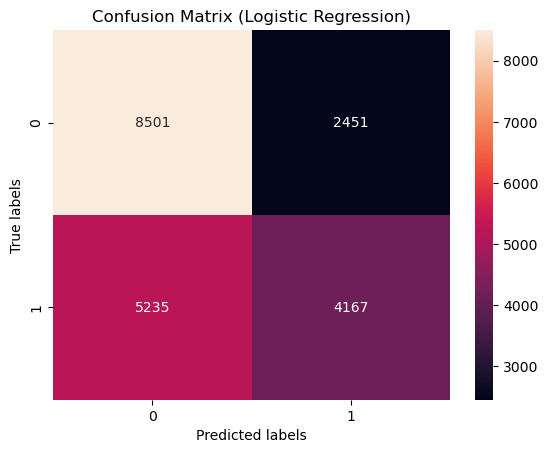

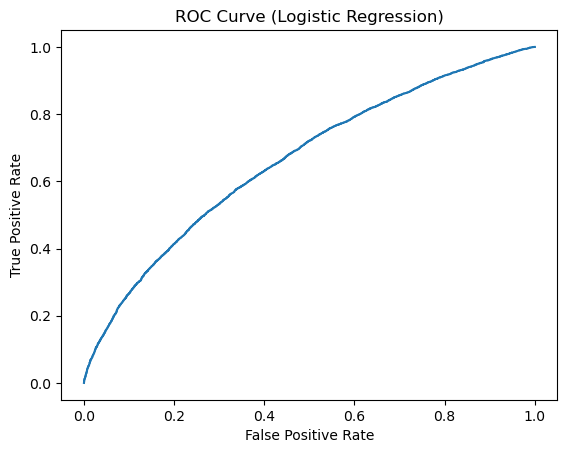

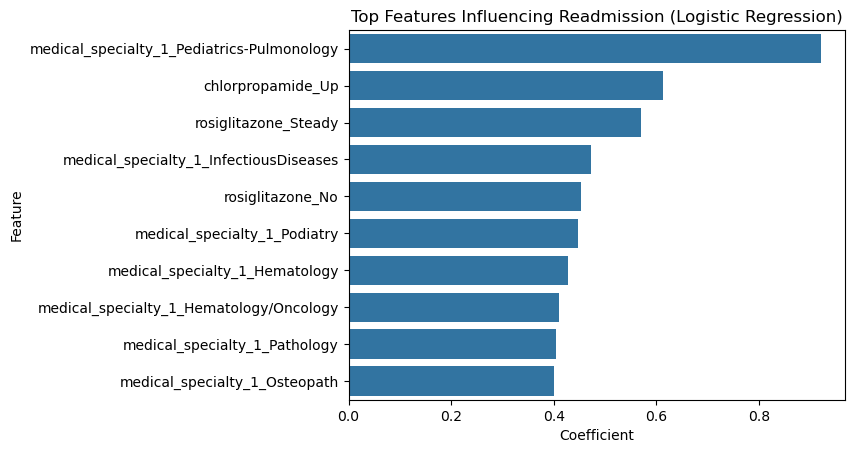

In [31]:
## Evaluation model (Logistic Regression)
# 1) Accuracy
from sklearn.metrics import accuracy_score
print('Accuracy score (Logistic Regression):', accuracy_score(y_test, y_pred_LogisticReg))

# 2) lassification report
from sklearn.metrics import classification_report
print('Classification report (Logistic Regression):', classification_report(y_test, y_pred_LogisticReg))

# 3) Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_LogisticReg)
sns.heatmap(cm, annot = True, fmt = 'd')
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted labels');
plt.ylabel('True labels'); 
plt.show()

# 4) ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score
y_prob_LogisticReg = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_LogisticReg)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Logistic Regression)')
plt.show()

# 5) Feature importance
importance_LR = pd.DataFrame({
    'Feature':  X.columns,
    'Coefficient': model.coef_[0]
})
importance_LR_1 = importance_LR.sort_values(by='Coefficient', ascending = False)

# plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=importance_LR_1.head(10))
plt.title('Top Features Influencing Readmission (Logistic Regression)')
plt.show()


In [32]:
# save feature importance for Power BI
logistic_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

logistic_importance["Abs_Coefficient"] = logistic_importance["Coefficient"].abs()

logistic_importance = logistic_importance.sort_values(
    by="Coefficient", #by="Abs_Coefficient",
    ascending=False
)

logistic_importance.to_csv(
    '../notebooks/logistic_regression_feature_importance.csv',
    index=False
)

In [33]:
logistic_importance

,Feature,Coefficient,Abs_Coefficient
145,medical_specialty_1_Pediatrics-Pulmonology,0.920939,0.920939
44,chlorpropamide_Up,0.612639,0.612639
60,rosiglitazone_Steady,0.569965,0.569965
120,medical_specialty_1_InfectiousDiseases,0.472858,0.472858
59,rosiglitazone_No,0.452620,0.452620
...,...,...,...
164,medical_specialty_1_Surgery-Cardiovascular/Tho...,-0.571194,0.571194
134,medical_specialty_1_Otolaryngology,-0.617480,0.617480
65,miglitol_No,-0.689334,0.689334
141,medical_specialty_1_Pediatrics-Endocrinology,-0.717080,0.717080


In [34]:
##### Machine Learning ######
# classify readmission risk
# models: Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state = 42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [35]:
# prediction
rf_pred = rf.predict(X_test)

Accuracy score (RandomForest): 0.6320133634666405
Classification report (RandomForest):               precision    recall  f1-score   support

       False       0.64      0.73      0.68     10952
        True       0.62      0.52      0.56      9402

    accuracy                           0.63     20354
   macro avg       0.63      0.62      0.62     20354
weighted avg       0.63      0.63      0.63     20354



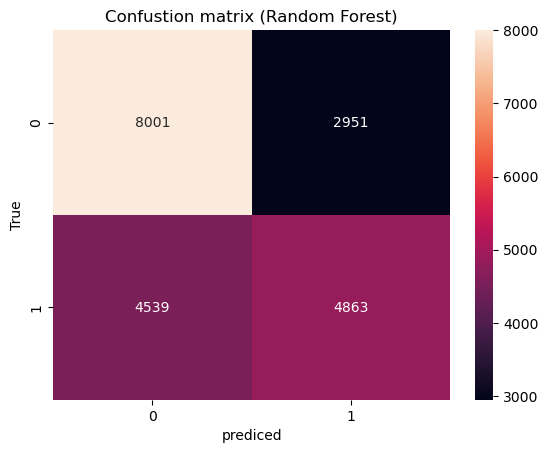

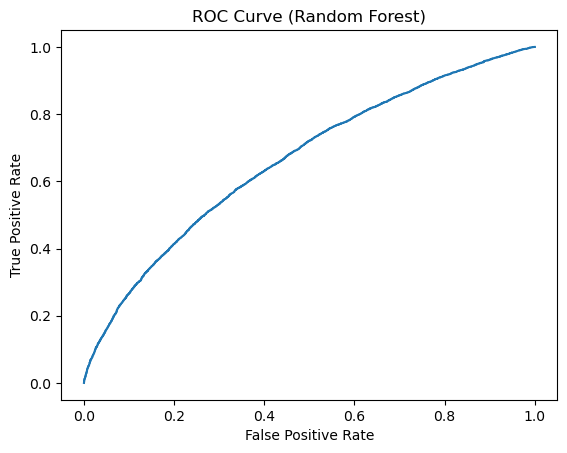

roc_auc_score: 0.6624495740069913


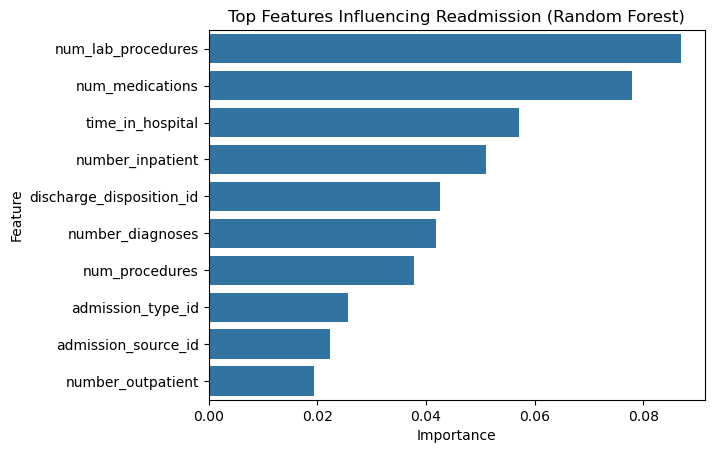

In [36]:
# 1) Accuracy of prediction
from sklearn.metrics import accuracy_score
print('Accuracy score (RandomForest):', accuracy_score(y_test, rf_pred))

# 2) classification report
from sklearn.metrics import classification_report
print('Classification report (RandomForest):', classification_report(y_test, rf_pred))

# 3) confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confustion matrix (Random Forest)')
plt.xlabel('prediced')
plt.ylabel('True')
plt.show()

# 4) ROC curve, ROC_AUC_Score
from sklearn.metrics import roc_curve, roc_auc_score
rf_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Random Forest)')
plt.show()

print('roc_auc_score:', roc_auc_score(y_test, rf_prob))

# 5) Feature importance
import pandas as pd
importance_rf = rf.feature_importances_
importance_rf_1 = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance_rf
})
importance_rf_2 = importance_rf_1.sort_values(by='Importance', ascending=False)

#plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_rf_2.head(10))
plt.title('Top Features Influencing Readmission (Random Forest)')
plt.show()

#plt.figure(figsize=(10,6))
#sns.barplot(x='Importance', y='Feature', data=importance_rf_2.head(5))
#plt.title('Top Features Influencing Readmission (Random Forest)')
#plt.show()

In [37]:
# save importance of random forest
importance_rf_2.to_csv(
    '../notebooks/random_forest_feature_importance.csv',
    index=False
)

In [38]:
X_train.describe()
y_train.info()


<class 'pandas.core.series.Series'>
Index: 81412 entries, 24079 to 15795
Series name: readmitted_binary_Yes
Non-Null Count  Dtype
--------------  -----
81412 non-null  bool 
dtypes: bool(1)
memory usage: 715.5 KB


In [39]:
## XGBoost #####
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
#xgb.fit(X_train, y_train) # 'ValueError: feature_names must be string, and may not contain [, ] or <'

# Pass the underlying array instead of the DataFrame
xgb.fit(X_train.values, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [40]:
# prediction
xgb_pred = xgb.predict(X_test)

Accuracy score (XGBoost): 0.6456716124594675
Classification score (XGBoost):               precision    recall  f1-score   support

       False       0.66      0.72      0.69     10952
        True       0.63      0.56      0.59      9402

    accuracy                           0.65     20354
   macro avg       0.64      0.64      0.64     20354
weighted avg       0.64      0.65      0.64     20354



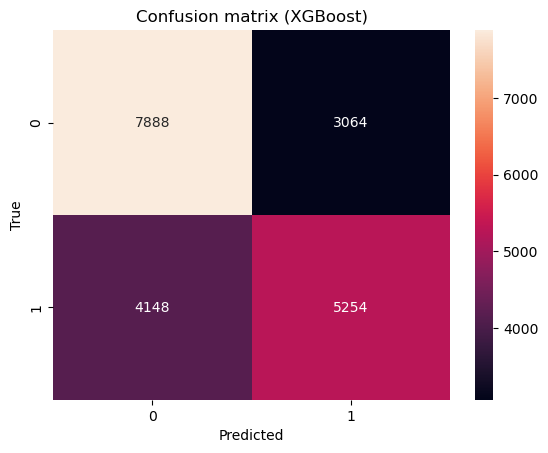

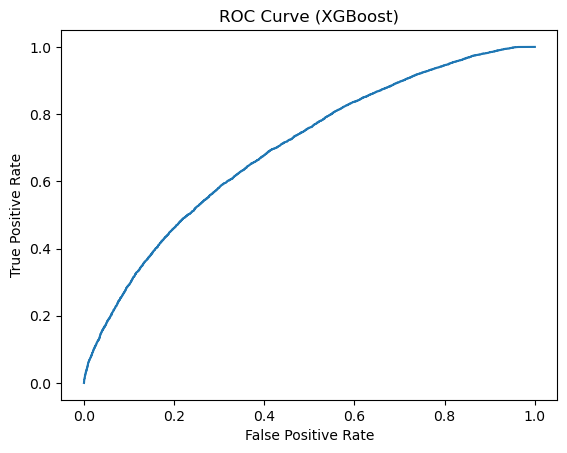

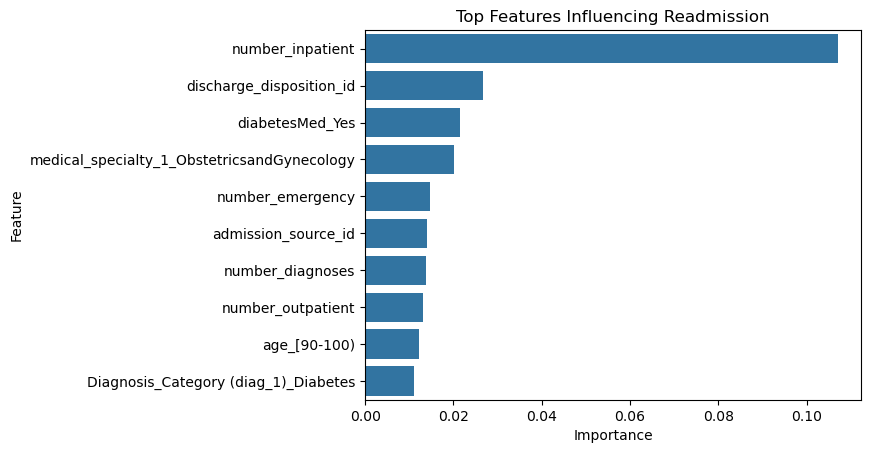

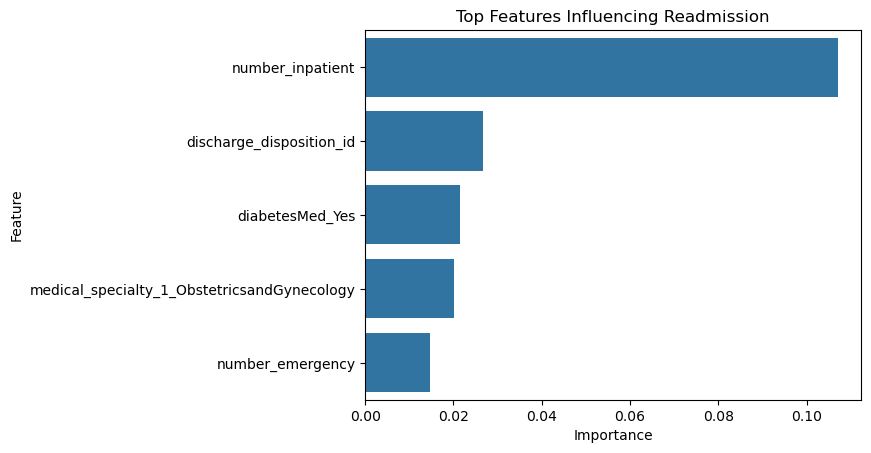

In [41]:
# 1) Accuracy score
from sklearn.metrics import accuracy_score
print('Accuracy score (XGBoost):', accuracy_score(y_test, xgb_pred))

# 2) classification report
from sklearn.metrics import classification_report
print('Classification score (XGBoost):', classification_report(y_test, xgb_pred))

# 3) Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot = True, fmt='d')
plt.title('Confusion matrix (XGBoost)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 4) ROC curve roc_auc_score
from sklearn.metrics import roc_curve, roc_auc_score
xgb_prob = xgb.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, xgb_prob)
plt.plot(fpr, tpr)
plt.title('ROC Curve (XGBoost)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

# 5) Feature importance
importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})
importance_xgb_1 = importance_xgb.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance_xgb_1.head(10))
plt.title('Top Features Influencing Readmission')
plt.show()

sns.barplot(x='Importance', y='Feature', data=importance_xgb_1.head(5))
plt.title('Top Features Influencing Readmission')
plt.show()

In [42]:
# save importance of xgboost model
importance_xgb_1.to_csv(
    '../notebooks/xgboost_feature_importance.csv',
    index=False
)

In [43]:
# save data to use analysis
df.to_csv("diabetes_risk prediction_data.csv", index=False)
df1.to_csv("diabetes_risk prediction_data_ML.csv", index=False)

In [44]:
# Compute metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

logistic_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_LogisticReg),
    "Precision": precision_score(y_test, y_pred_LogisticReg),
    "Recall": recall_score(y_test, y_pred_LogisticReg),
    "F1": f1_score(y_test, y_pred_LogisticReg),
    "ROC_AUC": roc_auc_score(
        y_test, model.predict_proba(X_test)[:,1]
    )
}

rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred),
    "ROC_AUC": roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]
    )
}

xgb_metrics = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1": f1_score(y_test, xgb_pred),
    "ROC_AUC": roc_auc_score(
        y_test, xgb.predict_proba(X_test)[:,1]
    )
}

metrics_ml = pd.DataFrame([
    logistic_metrics,
    rf_metrics,
    xgb_metrics
])

metrics_ml

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.622384,0.629646,0.443204,0.520225,0.662450
1,Random Forest,0.632013,0.622345,0.517230,0.564940,0.683209
2,XGBoost,0.645672,0.631642,0.558817,0.593002,0.697785


In [45]:
metrics_ml.to_csv(
    "model_performance_metrics.csv",
    index=False
)